# PHASE 1 : Chargement, exploration, prétraitement


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import iplot, plot
from sklearn.preprocessing import LabelEncoder



## Chargement


In [3]:
df = pd.read_csv("..\\data\\heart.csv")

print("Shape :", df.shape)
print("\nAperçu :")
print(df.head())

print("\nTypes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

print("\nStatistiques descriptives :")
print(df.describe())
print(f"Doublons : {df.duplicated().sum()}")


Shape : (918, 12)

Aperçu :
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Types :
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG    

## Exploration


In [5]:
sex = df['Sex'].value_counts().reset_index()
sex

,Sex,count
0,M,725
1,F,193


C:\Users\khaye\AppData\Local\Temp\ipykernel_32620\1741947395.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='count', data=sex, palette='viridis')


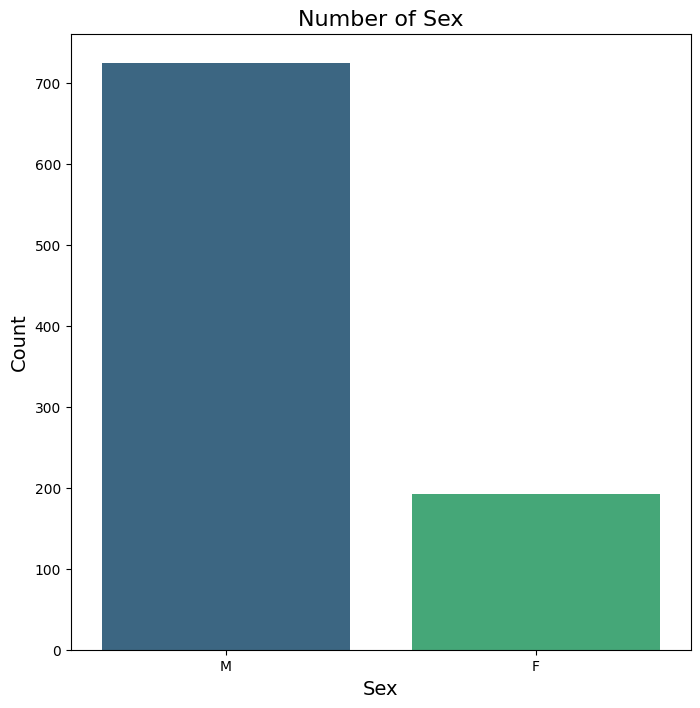

In [7]:
plt.figure(figsize=(8, 8))
sns.barplot(x='Sex', y='count', data=sex, palette='viridis')
plt.xlabel('Sex', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Number of Sex', fontsize=16)
plt.savefig("../outputs/figures/target_distribution.png")
plt.show()

In [8]:
ChestPainType = df['ChestPainType'].value_counts().reset_index()
ChestPainType

,ChestPainType,count
0,ASY,496
1,NAP,203
2,ATA,173
3,TA,46


C:\Users\khaye\AppData\Local\Temp\ipykernel_32620\2752706621.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ChestPainType', y='count', data=ChestPainType, palette='viridis')


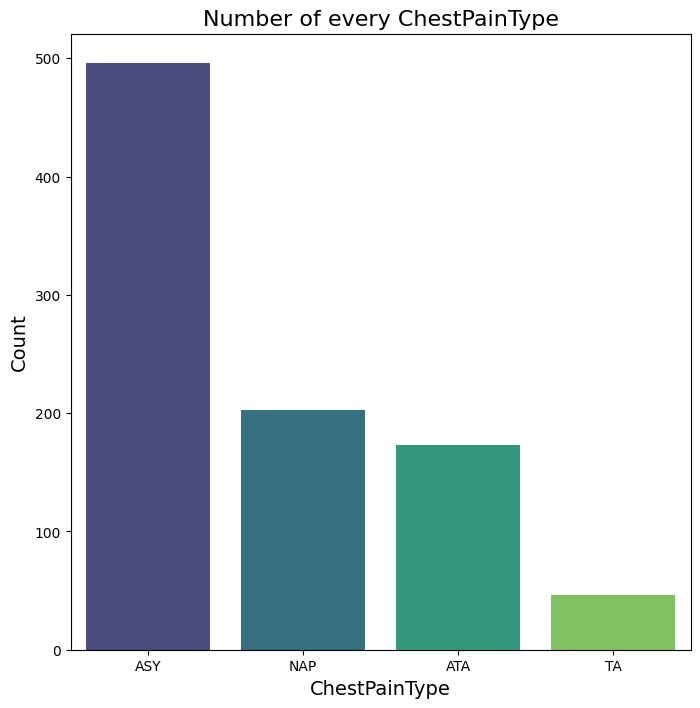

In [9]:
plt.figure(figsize=(8, 8))
sns.barplot(x='ChestPainType', y='count', data=ChestPainType, palette='viridis')
plt.xlabel('ChestPainType', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Number of every ChestPainType', fontsize=16)
plt.savefig("../outputs/figures/ChestPainType_distribution.png")
plt.show()

In [10]:
RestingECG = df['RestingECG'].value_counts().reset_index()
RestingECG

,RestingECG,count
0,Normal,552
1,LVH,188
2,ST,178


C:\Users\khaye\AppData\Local\Temp\ipykernel_32620\2818700662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RestingECG', y='count', data=RestingECG, palette='viridis')


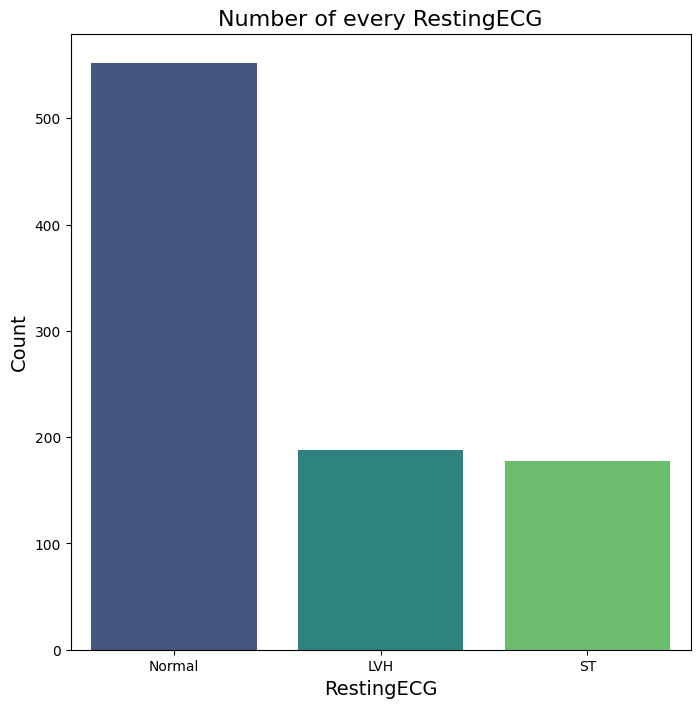

In [11]:
plt.figure(figsize=(8, 8))
sns.barplot(x='RestingECG', y='count', data=RestingECG, palette='viridis')
plt.xlabel('RestingECG', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Number of every RestingECG', fontsize=16)
plt.savefig("../outputs/figures/RestingECG_distribution.png")
plt.show()

In [14]:
ST_Slope = df['ST_Slope'].value_counts().reset_index()
ST_Slope

,ST_Slope,count
0,Flat,460
1,Up,395
2,Down,63


C:\Users\khaye\AppData\Local\Temp\ipykernel_32620\4248531406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ST_Slope', y='count', data=ST_Slope, palette='viridis')


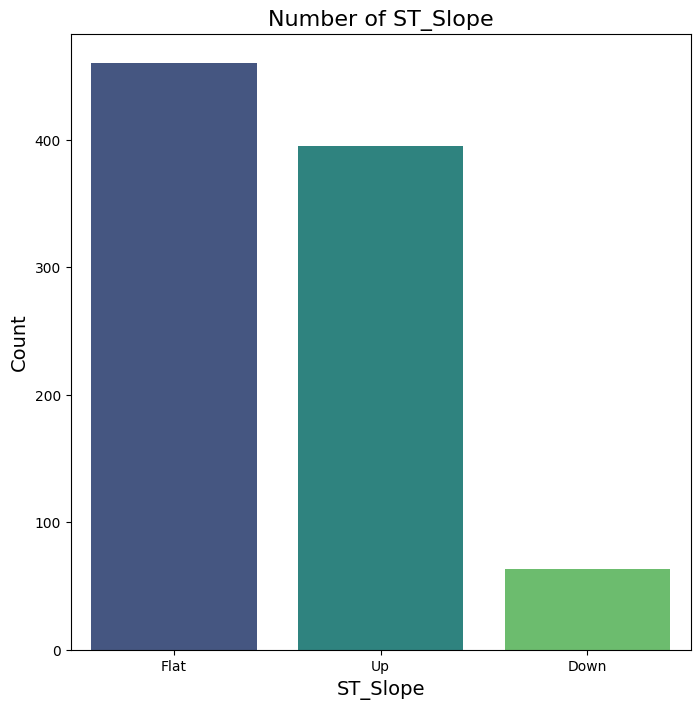

In [15]:
plt.figure(figsize=(8, 8))
sns.barplot(x='ST_Slope', y='count', data=ST_Slope, palette='viridis')
plt.xlabel('ST_Slope', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Number of ST_Slope', fontsize=16)
plt.savefig("../outputs/figures/ST_Slope_distribution.png")
plt.show()

In [16]:
HeartDisease = df['HeartDisease'].value_counts().reset_index()
HeartDisease

,HeartDisease,count
0,1,508
1,0,410


C:\Users\khaye\AppData\Local\Temp\ipykernel_32620\1099194730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='HeartDisease', y='count', data=HeartDisease, palette='viridis')


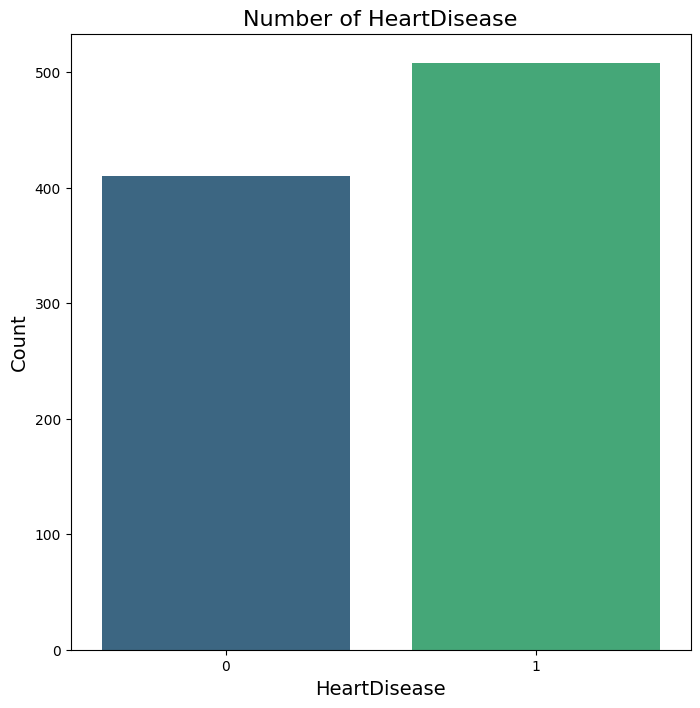

In [17]:
plt.figure(figsize=(8, 8))
sns.barplot(x='HeartDisease', y='count', data=HeartDisease, palette='viridis')
plt.xlabel('HeartDisease', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Number of HeartDisease', fontsize=16)
plt.savefig("../outputs/figures/HeartDisease_distribution.png")
plt.show()

In [30]:


histogram_labels = ['Age',
                    'RestingBP', 
                    'Cholesterol', 
                    'MaxHR', 
                    'Oldpeak', 
                   ]

colors = px.colors.qualitative.Vivid
for i in range(len(histogram_labels)):
    fig = px.histogram(df, 
                       histogram_labels[i], 
                       title=f'{histogram_labels[i]} distribution in top hits', 
                       color_discrete_sequence=[colors[i]]
                      )

    iplot(fig)

## Prepocessing the Data 

In [31]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Column HeartDisease is target Column and will encoder Columns ChestPainType, Sex, RestingBP, ST_Slope, ExerciseAngina**

In [ ]:
le = LabelEncoder()

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\khaye\AppData\Local\Temp\ipykernel_32620\2023511143.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [36]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,1,132,0,1.2,1,1
914,68,1,0,144,193,1,1,141,0,3.4,1,1
915,57,1,0,130,131,0,1,115,1,1.2,1,1
916,57,0,1,130,236,0,0,174,0,0.0,1,1


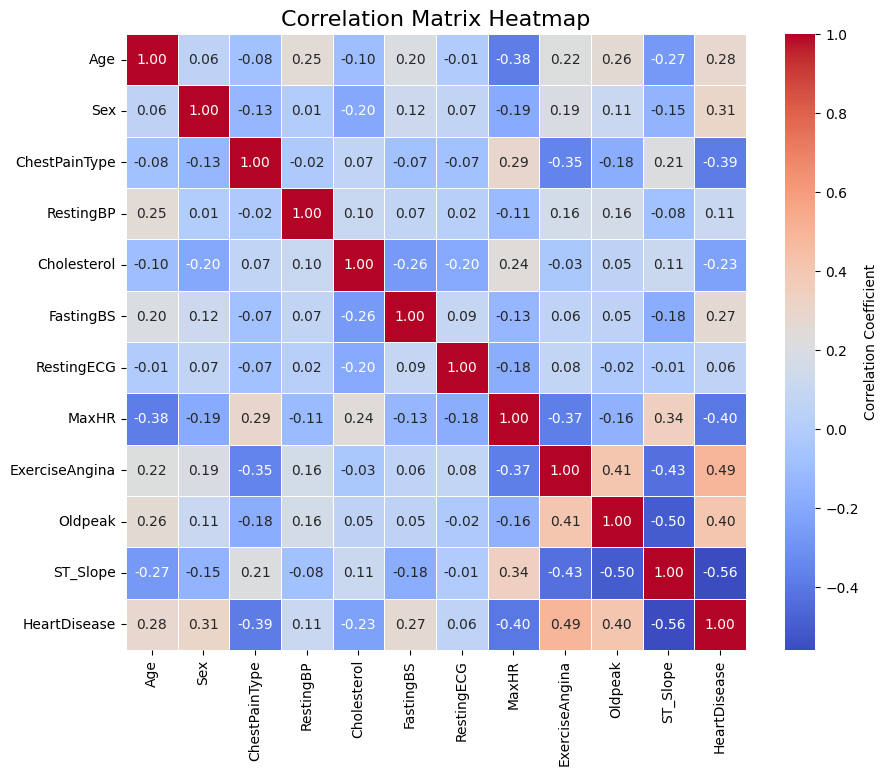

In [38]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f", cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix Heatmap', fontsize=16)

plt.show()